In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


import seaborn as sns
from sklearn.metrics import confusion_matrix


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping


In [35]:
# # data = pd.read_csv("/content/sample_data/mnist_test.csv")
# # data2 = pd.read_csv("/content/sample_data/mnist_train_small.csv")

# data = pd.read_csv("Sensorless_drive_diagnosis.txt")

In [36]:
# Load raw dataset
sensorless_raw_df = pd.read_csv(
    "/content/Sensorless_drive_diagnosis.txt",
    sep=r"\s+",
    header=None
)

# Separate features and target
sensorless_features = sensorless_raw_df.iloc[:, :-1]
sensorless_target = sensorless_raw_df.iloc[:, -1]

print("Features shape:", sensorless_features.shape)
print("Target shape:", sensorless_target.shape)


Features shape: (58509, 48)
Target shape: (58509,)


In [37]:

# Train + temporary split
X_train_sensorless, X_temp_sensorless, y_train_sensorless, y_temp_sensorless = train_test_split(
    sensorless_features,
    sensorless_target,
    test_size=0.30,
    stratify=sensorless_target,
    random_state=42
)

# Validation + test split
X_val_sensorless, X_test_sensorless, y_val_sensorless, y_test_sensorless = train_test_split(
    X_temp_sensorless,
    y_temp_sensorless,
    test_size=0.50,
    stratify=y_temp_sensorless,
    random_state=42
)

print(X_train_sensorless.shape, X_val_sensorless.shape, X_test_sensorless.shape)


(40956, 48) (8776, 48) (8777, 48)


In [38]:

sensorless_scaler = StandardScaler()

X_train_sensorless = sensorless_scaler.fit_transform(X_train_sensorless)
X_val_sensorless   = sensorless_scaler.transform(X_val_sensorless)
X_test_sensorless  = sensorless_scaler.transform(X_test_sensorless)


In [39]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

sensorless_label_encoder = LabelEncoder()

y_train_encoded = sensorless_label_encoder.fit_transform(y_train_sensorless)
y_val_encoded   = sensorless_label_encoder.transform(y_val_sensorless)
y_test_encoded  = sensorless_label_encoder.transform(y_test_sensorless)

sensorless_num_classes = len(set(y_train_encoded))

y_train_categorical = to_categorical(y_train_encoded, sensorless_num_classes)
y_val_categorical   = to_categorical(y_val_encoded, sensorless_num_classes)
y_test_categorical  = to_categorical(y_test_encoded, sensorless_num_classes)


In [40]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

sensorless_fnn_model = Sequential([
    Dense(128, activation="relu", input_shape=(X_train_sensorless.shape[1],)),
    Dropout(0.3),

    Dense(64, activation="relu"),
    Dropout(0.3),

    Dense(sensorless_num_classes, activation="softmax")
])

sensorless_fnn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

sensorless_fnn_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 11)             │           715 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,243 (59.54 KB)

 Trainable params: 15,243 (59.54 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
sensorless_training_history = sensorless_fnn_model.fit(
    X_train_sensorless,
    y_train_categorical,
    validation_data=(X_val_sensorless, y_val_categorical),
    epochs=10,
    batch_size=256,
    verbose=1
)


Epoch 1/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.2812 - loss: 2.0112 - val_accuracy: 0.7713 - val_loss: 0.7954
Epoch 2/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6704 - loss: 0.8830 - val_accuracy: 0.8794 - val_loss: 0.3893
Epoch 3/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7963 - loss: 0.5387 - val_accuracy: 0.9087 - val_loss: 0.2843
Epoch 4/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8349 - loss: 0.4309 - val_accuracy: 0.9300 - val_loss: 0.2321
Epoch 5/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8670 - loss: 0.3574 - val_accuracy: 0.9389 - val_loss: 0.1976
Epoch 6/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8829 - loss: 0.3181 - val_accuracy: 0.9497 - val_loss: 0.1725
Epoch 7/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8921 - loss: 0.2911 - val_accuracy: 0.9550 - val_loss: 0.1563
Epoch 8/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9066 - loss: 0.2553 - val_accuracy: 0.

In [42]:
test_loss, test_accuracy = sensorless_fnn_model.evaluate(
    X_test_sensorless,
    y_test_categorical,
    verbose=0
)

print("Sensorless Drive Diagnosis Test Loss:", test_loss)
print("Sensorless Drive Diagnosis Test Accuracy:", test_accuracy)


Sensorless Drive Diagnosis Test Loss: 0.12278511375188828
Sensorless Drive Diagnosis Test Accuracy: 0.963199257850647


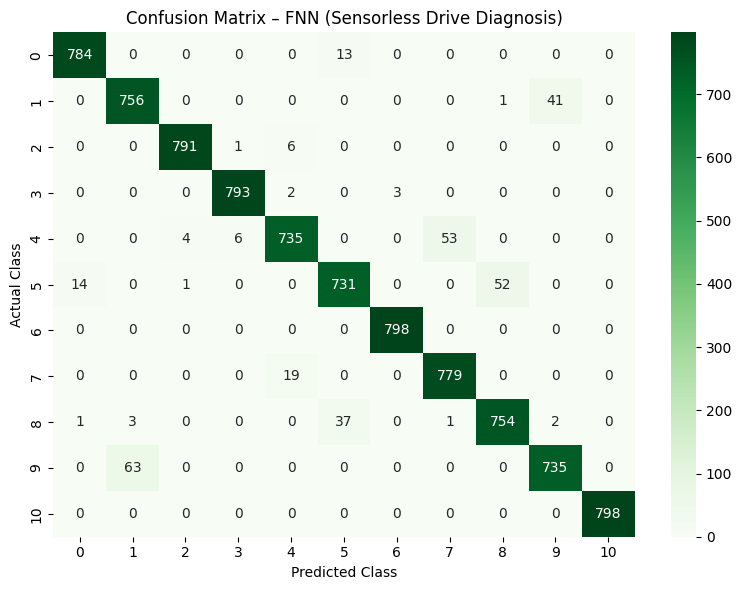

In [70]:
# Compute confusion matrix
cm_fnn = confusion_matrix(y_test_encoded, y_test_pred_fnn)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_fnn,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix – FNN (Sensorless Drive Diagnosis)")
plt.tight_layout()
plt.show()


In [43]:
from sklearn.ensemble import RandomForestClassifier

sensorless_rf_model = RandomForestClassifier(
    n_estimators=200,        # number of trees
    max_depth=None,          # let trees grow fully
    min_samples_split=2,
    min_samples_leaf=1,
    bootstrap=True,
    n_jobs=-1,               # use all CPU cores
    random_state=42
)


In [44]:
sensorless_rf_model.fit(
    X_train_sensorless,
    y_train_sensorless
)


RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [45]:
from sklearn.metrics import accuracy_score

y_val_pred_rf = sensorless_rf_model.predict(X_val_sensorless)
val_accuracy_rf = accuracy_score(y_val_sensorless, y_val_pred_rf)

print("Validation Accuracy (Random Forest):", val_accuracy_rf)


Validation Accuracy (Random Forest): 0.9982907930720146


In [46]:
y_test_pred_rf = sensorless_rf_model.predict(X_test_sensorless)
test_accuracy_rf = accuracy_score(y_test_sensorless, y_test_pred_rf)

print("Test Accuracy (Random Forest):", test_accuracy_rf)


Test Accuracy (Random Forest): 0.9990885268314914


In [64]:
sample_index = 0

sensorless_sample = X_test_sensorless[sample_index].reshape(1, -1)

sample_prediction = sensorless_rf_model.predict(sensorless_sample)
sample_probabilities = sensorless_rf_model.predict_proba(sensorless_sample)

print("Predicted class:", sample_prediction[0])
print("Class probabilities:", sample_probabilities)
print("Actual class:", y_test_sensorless.iloc[sample_index])

Predicted class: 2
Class probabilities: [[0.   0.94 0.   0.   0.   0.   0.   0.   0.   0.06 0.  ]]
Actual class: 2


In [65]:
y_test_pred_rf = sensorless_rf_model.predict(X_test_sensorless)

y_test_pred_fnn_prob = sensorless_fnn_model.predict(X_test_sensorless)
y_test_pred_fnn = np.argmax(y_test_pred_fnn_prob, axis=1)


275/275 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


In [66]:
from sklearn.metrics import accuracy_score

rf_test_accuracy = accuracy_score(y_test_sensorless, y_test_pred_rf)
fnn_test_accuracy = accuracy_score(y_test_encoded, y_test_pred_fnn)

print("Random Forest Test Accuracy:", rf_test_accuracy)
print("FNN Test Accuracy:", fnn_test_accuracy)


Random Forest Test Accuracy: 0.9990885268314914
FNN Test Accuracy: 0.9631992708214652


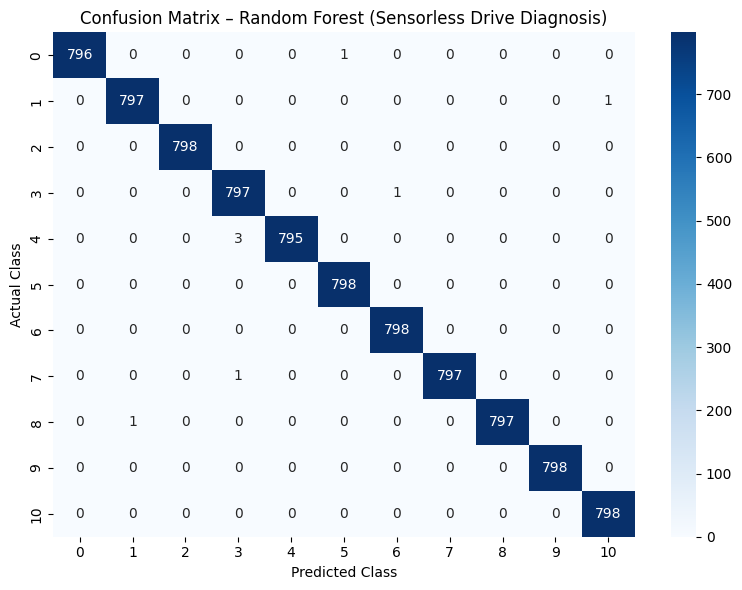

In [69]:
# Compute confusion matrix
cm_rf = confusion_matrix(y_test_sensorless, y_test_pred_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix – Random Forest (Sensorless Drive Diagnosis)")
plt.tight_layout()
plt.show()
